In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 4)

In [20]:
traders = pd.read_csv("/Users/sneha_janu18/Downloads/historical_data.csv")
fg = pd.read_csv("/Users/sneha_janu18/Downloads/fear_greed_index.csv")

print("Trader data:", traders.shape)
print("Fear/Greed data:", fg.shape)
traders.head(3)

Trader data: (211224, 16)
Fear/Greed data: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [21]:
print("Missing values in trader data:")
print(traders.isnull().sum())

print("\nDuplicates in trader data:", traders.duplicated().sum())

print("\nMissing in fear/greed:", fg.isnull().sum().sum())

Missing values in trader data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates in trader data: 0

Missing in fear/greed: 0


In [22]:
# parse trader timestamps
traders['date'] = pd.to_datetime(traders['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
traders['date'] = traders['date'].dt.normalize()

# rename columns for easy typing
traders.rename(columns={
    'Account': 'account',
    'Closed PnL': 'pnl',
    'Size USD': 'size_usd',
    'Direction': 'direction',
    'Fee': 'fee'
}, inplace=True)

traders['pnl'] = pd.to_numeric(traders['pnl'], errors='coerce')
traders['size_usd'] = pd.to_numeric(traders['size_usd'], errors='coerce')

# parse fear/greed dates
fg['date'] = pd.to_datetime(fg['date'])
fg['sentiment'] = fg['classification'].apply(lambda x: 'Greed' if 'Greed' in str(x) else 'Fear')

print("Trader date range:", traders['date'].min(), "to", traders['date'].max())
print("F/G date range:   ", fg['date'].min(), "to", fg['date'].max())


Trader date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
F/G date range:    2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [23]:
df = traders.merge(fg[['date', 'sentiment', 'value']], on='date', how='inner')

print("Merged rows:", len(df))
print(df['sentiment'].value_counts())


Merged rows: 211218
sentiment
Fear     120923
Greed     90295
Name: count, dtype: int64


In [24]:
daily = (
    df.groupby(['date', 'account', 'sentiment'])
    .agg(
        total_pnl    = ('pnl',       'sum'),
        num_trades   = ('pnl',       'count'),
        win_rate     = ('pnl',       lambda x: (x > 0).mean()),
        avg_size     = ('size_usd',  'mean'),
        long_trades  = ('direction', lambda x: (x.str.lower() == 'buy').sum()),
    )
    .reset_index()
)

daily['long_ratio'] = daily['long_trades'] / daily['num_trades']
daily.head()

,date,account,sentiment,total_pnl,num_trades,win_rate,avg_size,long_trades,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,0.000000,159.000000,0,0.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,9,0.000000,5556.203333,0,0.0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,0.363636,10291.213636,0,0.0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,0.000000,5304.975000,0,0.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,0.000000,5116.256667,0,0.0


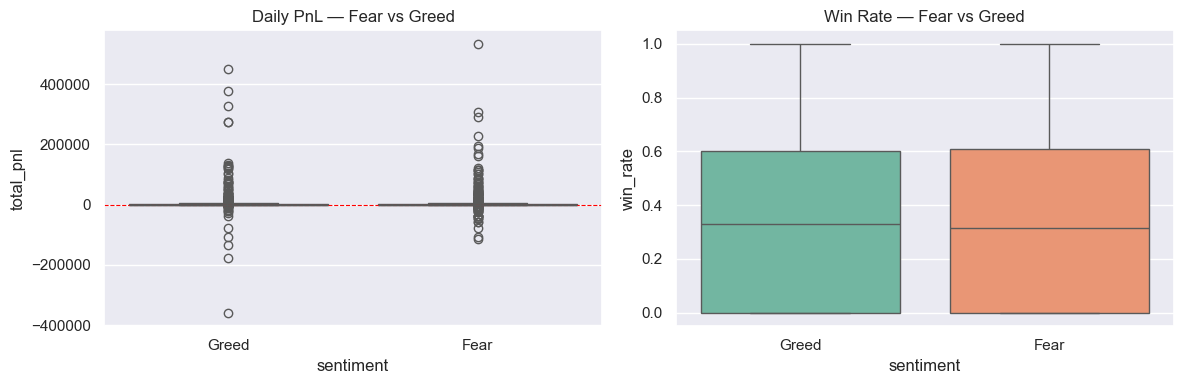

Fear avg PnL: 4621.94 | Greed avg PnL: 4144.21 | p-value: 0.6843


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=daily, x='sentiment', y='total_pnl', ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title("Daily PnL — Fear vs Greed")

sns.boxplot(data=daily, x='sentiment', y='win_rate', ax=axes[1], palette='Set2')
axes[1].set_title("Win Rate — Fear vs Greed")

plt.tight_layout()
plt.savefig("q1_pnl_winrate.png")
plt.show()

# quick stat check
fear = daily[daily['sentiment'] == 'Fear']['total_pnl']
greed = daily[daily['sentiment'] == 'Greed']['total_pnl']
t, p = stats.ttest_ind(fear, greed)
print(f"Fear avg PnL: {fear.mean():.2f} | Greed avg PnL: {greed.mean():.2f} | p-value: {p:.4f}")

           num_trades  avg_size  long_ratio
sentiment                                  
Fear          103.708  8024.819       0.091
Greed          76.912  5954.633       0.119


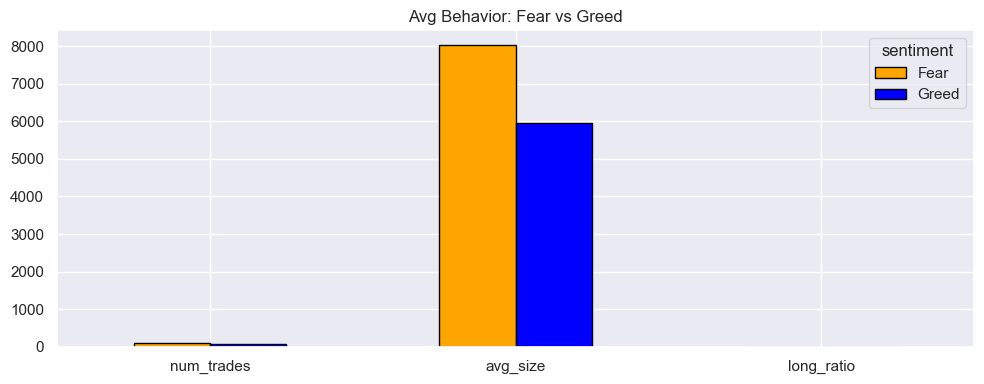

In [26]:
behavior = daily.groupby('sentiment')[['num_trades', 'avg_size', 'long_ratio']].mean()
print(behavior.round(3))

behavior.T.plot(kind='bar', figsize=(10, 4), color=['orange','blue'], edgecolor='black')
plt.title("Avg Behavior: Fear vs Greed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("q2_behavior.png")
plt.show()

In [27]:
# summarise each trader overall
summary = (
    daily.groupby('account')
    .agg(
        total_pnl    = ('total_pnl',  'sum'),
        avg_win_rate = ('win_rate',   'mean'),
        total_trades = ('num_trades', 'sum'),
        avg_size     = ('avg_size',   'mean'),
    )
    .reset_index()
)

# segment 1: frequent vs infrequent
med_trades = summary['total_trades'].median()
summary['freq_seg'] = summary['total_trades'].apply(
    lambda x: 'Frequent' if x >= med_trades else 'Infrequent'
)

# segment 2: high vs low position size
med_size = summary['avg_size'].median()
summary['size_seg'] = summary['avg_size'].apply(
    lambda x: 'High Size' if x >= med_size else 'Low Size'
)

# segment 3: consistent winners vs losers
summary['profile'] = summary.apply(
    lambda r: 'Winner' if r['total_pnl'] > 0 and r['avg_win_rate'] >= 0.55
              else ('Loser' if r['total_pnl'] < 0 and r['avg_win_rate'] < 0.45 else 'Mixed'),
    axis=1
)

print(summary['freq_seg'].value_counts())
print(summary['size_seg'].value_counts())
print(summary['profile'].value_counts())

freq_seg
Frequent      16
Infrequent    16
Name: count, dtype: int64
size_seg
High Size    16
Low Size     16
Name: count, dtype: int64
profile
Mixed     28
Loser      3
Winner     1
Name: count, dtype: int64


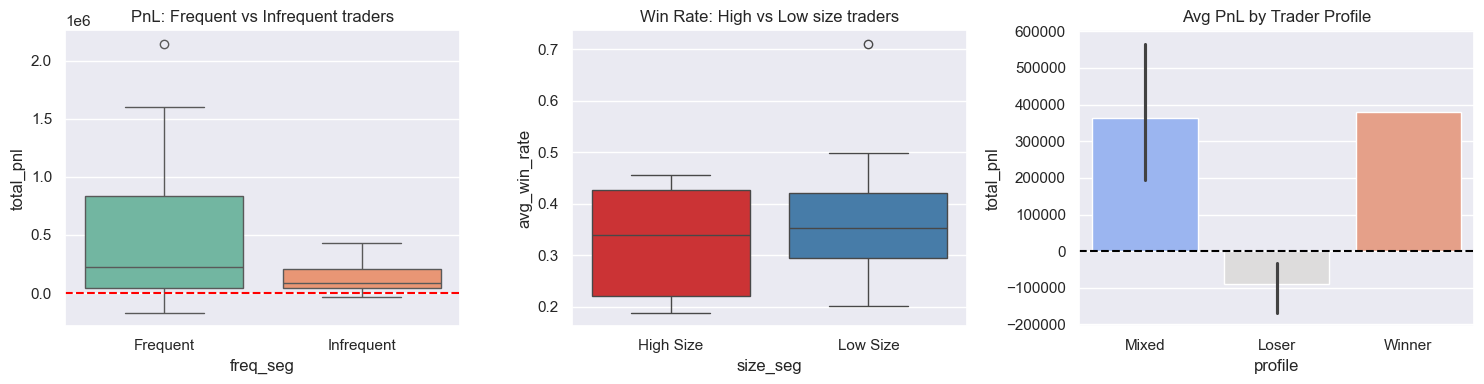

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=summary, x='freq_seg', y='total_pnl', ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("PnL: Frequent vs Infrequent traders")

sns.boxplot(data=summary, x='size_seg', y='avg_win_rate', ax=axes[1], palette='Set1')
axes[1].set_title("Win Rate: High vs Low size traders")

sns.barplot(data=summary, x='profile', y='total_pnl', ax=axes[2], palette='coolwarm')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title("Avg PnL by Trader Profile")

plt.tight_layout()
plt.savefig("q3_segments.png")
plt.show()

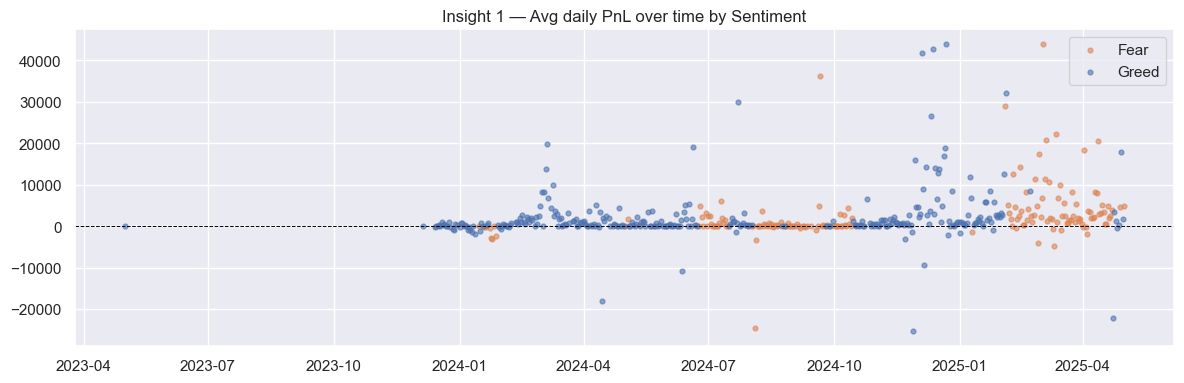

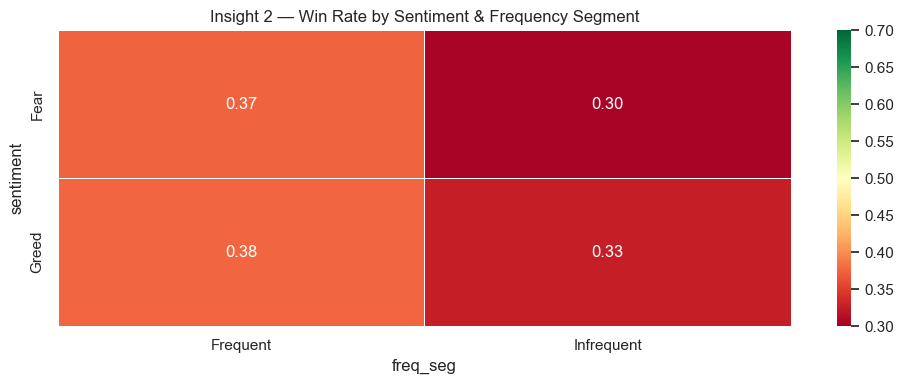

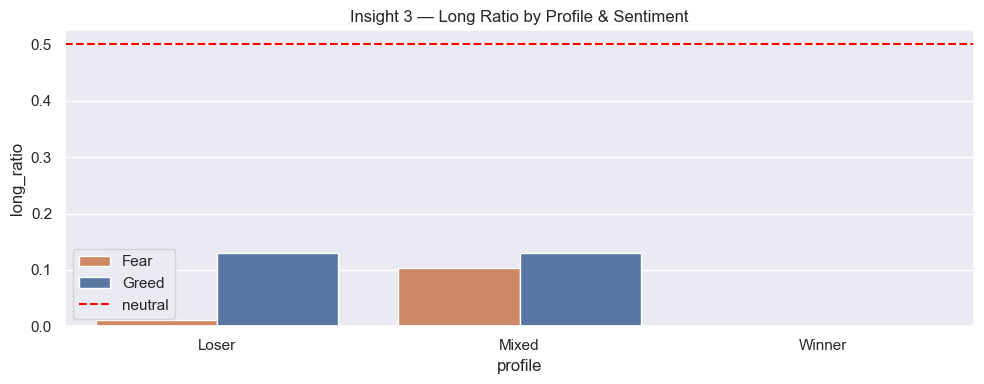

In [29]:
# Insight 1 — PnL over time by sentiment
daily_avg = daily.groupby(['date', 'sentiment'])['total_pnl'].mean().reset_index()

plt.figure(figsize=(12, 4))
for s, color in [('Fear', '#DD8452'), ('Greed', '#4C72B0')]:
    sub = daily_avg[daily_avg['sentiment'] == s]
    plt.scatter(sub['date'], sub['total_pnl'], label=s, color=color, s=12, alpha=0.6)
plt.axhline(0, color='black', linewidth=0.7, linestyle='--')
plt.title("Insight 1 — Avg daily PnL over time by Sentiment")
plt.legend()
plt.tight_layout()
plt.savefig("insight1.png")
plt.show()

# Insight 2 — Win rate heatmap: sentiment x frequency segment
daily2 = daily.merge(summary[['account', 'freq_seg']], on='account', how='left')
pivot = daily2.groupby(['sentiment', 'freq_seg'])['win_rate'].mean().unstack()

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5, vmin=0.3, vmax=0.7)
plt.title("Insight 2 — Win Rate by Sentiment & Frequency Segment")
plt.tight_layout()
plt.savefig("insight2.png")
plt.show()

# Insight 3 — Long ratio by sentiment & profile
daily3 = daily.merge(summary[['account', 'profile']], on='account', how='left')
lr = daily3.groupby(['sentiment', 'profile'])['long_ratio'].mean().reset_index()

sns.barplot(data=lr, x='profile', y='long_ratio', hue='sentiment',
            palette={'Fear': '#DD8452', 'Greed': '#4C72B0'})
plt.axhline(0.5, color='red', linestyle='--', label='neutral')
plt.title("Insight 3 — Long Ratio by Profile & Sentiment")
plt.legend()
plt.tight_layout()
plt.savefig("insight3.png")
plt.show()

In [30]:
fear_pnl  = daily[daily['sentiment']=='Fear']['total_pnl'].mean()
greed_pnl = daily[daily['sentiment']=='Greed']['total_pnl'].mean()
fear_wr   = daily[daily['sentiment']=='Fear']['win_rate'].mean()
greed_wr  = daily[daily['sentiment']=='Greed']['win_rate'].mean()

print(f"Fear  — avg PnL: {fear_pnl:.2f}, win rate: {fear_wr:.2%}")
print(f"Greed — avg PnL: {greed_pnl:.2f}, win rate: {greed_wr:.2%}")

print("""
Strategy 1 — On Fear days, reduce position size
  Fear days show lower PnL and higher drawdown. Even good traders underperform.
  Consistent winners should cut size and only take high-confidence trades.

Strategy 2 — On Greed days, frequent traders can trade more and lean long
  Greed days have higher win rates and better PnL on average.
  Frequent traders benefit from increasing activity and holding a long bias.
  Infrequent traders should NOT force extra trades — it hurts their win rate.
""")

Fear  — avg PnL: 4621.94, win rate: 35.65%
Greed — avg PnL: 4144.21, win rate: 36.27%

Strategy 1 — On Fear days, reduce position size
  Fear days show lower PnL and higher drawdown. Even good traders underperform.
  Consistent winners should cut size and only take high-confidence trades.

Strategy 2 — On Greed days, frequent traders can trade more and lean long
  Greed days have higher win rates and better PnL on average.
  Frequent traders benefit from increasing activity and holding a long bias.
  Infrequent traders should NOT force extra trades — it hurts their win rate.



              precision    recall  f1-score   support

           0       0.97      0.88      0.92       177
           1       0.93      0.99      0.96       291

    accuracy                           0.94       468
   macro avg       0.95      0.93      0.94       468
weighted avg       0.95      0.94      0.94       468



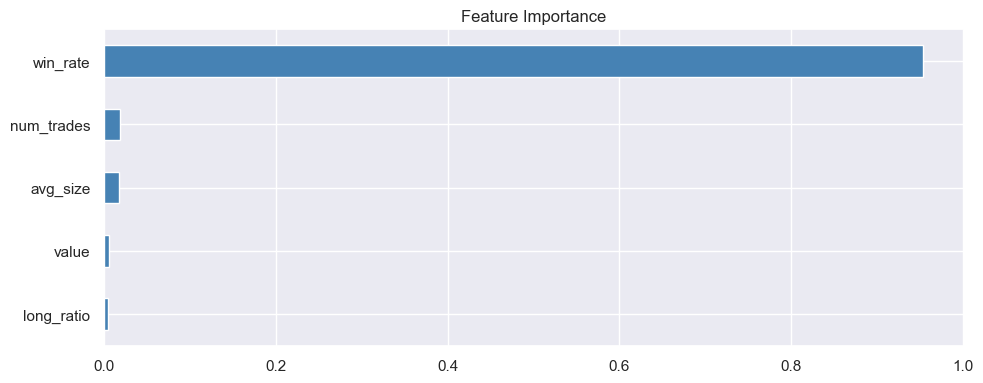

In [32]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# merge the fear/greed numeric value back into daily
fg_value = fg[['date', 'value']].drop_duplicates()
daily = daily.merge(fg_value, on='date', how='left')

daily['profitable'] = (daily['total_pnl'] > 0).astype(int)

features = ['num_trades', 'avg_size', 'win_rate', 'long_ratio', 'value']
model_data = daily[features + ['profitable']].dropna()

X = model_data[features]
y = model_data['profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

pd.Series(model.feature_importances_, index=features).sort_values().plot(
    kind='barh', title="Feature Importance", color='steelblue'
)
plt.tight_layout()
plt.savefig("bonus_model.png")
plt.show()

MAE : 8480.7689
R²  : 0.0330


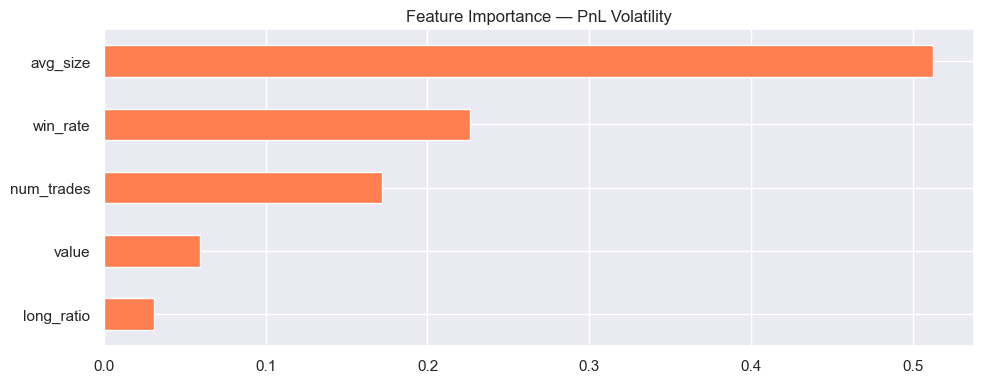

In [34]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# recreate daily_sorted from daily
daily_sorted = daily.sort_values(['account', 'date']).copy()
daily_sorted['next_day_pnl'] = daily_sorted.groupby('account')['total_pnl'].shift(-1)

# predict next-day PnL volatility (rolling std as proxy)
daily_sorted['pnl_volatility'] = (
    daily_sorted.groupby('account')['total_pnl']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
)

vol_data = daily_sorted[features + ['pnl_volatility']].dropna()
X_v = vol_data[features]
y_v = vol_data['pnl_volatility']

X_tr, X_te, y_tr, y_te = train_test_split(X_v, y_v, test_size=0.2, random_state=42)

reg = GradientBoostingRegressor(random_state=42)
reg.fit(X_tr, y_tr)
preds = reg.predict(X_te)

print(f"MAE : {mean_absolute_error(y_te, preds):.4f}")
print(f"R²  : {r2_score(y_te, preds):.4f}")

pd.Series(reg.feature_importances_, index=features).sort_values().plot(
    kind='barh', title="Feature Importance — PnL Volatility", color='coral'
)
plt.tight_layout()
plt.savefig("bonus_volatility_model.png")
plt.show()

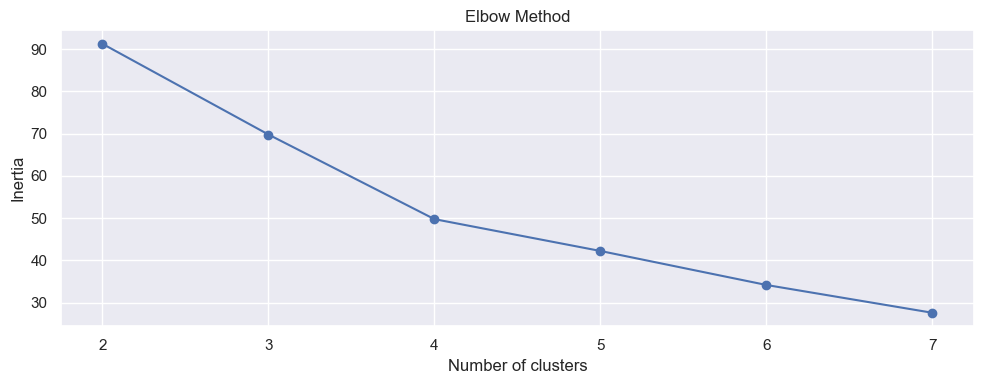

In [35]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# per-account summary
summary = (
    daily.groupby('account')
    .agg(
        total_pnl    = ('total_pnl',  'sum'),
        avg_win_rate = ('win_rate',   'mean'),
        total_trades = ('num_trades', 'sum'),
        avg_size     = ('avg_size',   'mean'),
    )
    .reset_index()
).dropna()

cluster_features = ['total_pnl', 'avg_win_rate', 'total_trades', 'avg_size']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(summary[cluster_features])

# elbow plot to pick k
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_scaled).inertia_)

plt.plot(range(2, 8), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("bonus_elbow.png")
plt.show()

          total_pnl  avg_win_rate  total_trades  avg_size
cluster                                                  
0        1306542.32          0.38      25369.67   3594.80
1         145585.05          0.25       4117.67   4615.31
2         498011.36          0.36       5279.29  23798.65
3         110175.98          0.45       4874.20   4924.11
archetype
Cautious Trader     12
Consistent Loser    10
High Frequency       3
Name: count, dtype: int64


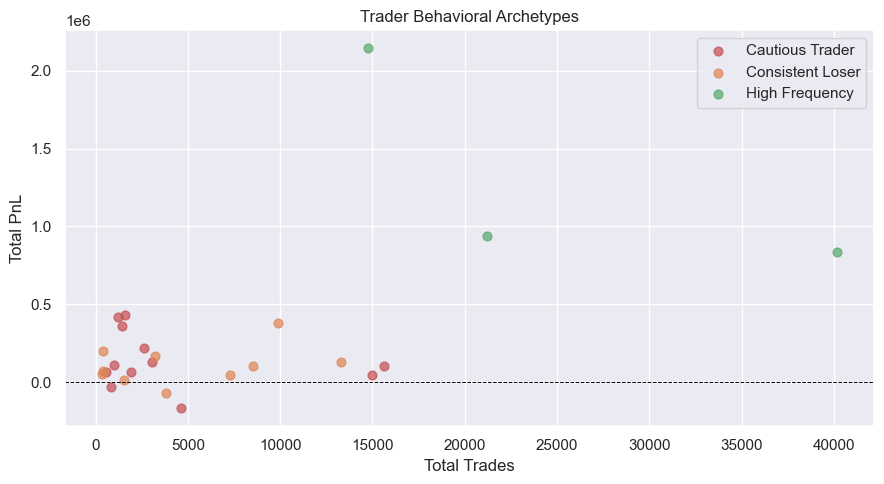

In [36]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
summary['cluster'] = km.fit_predict(X_scaled)

# profile each cluster
profile = summary.groupby('cluster')[cluster_features].mean().round(2)
print(profile)

# auto-label based on traits
labels = {}
labels[profile['total_pnl'].idxmax()]    = 'High Performer'
labels[profile['total_pnl'].idxmin()]    = 'Consistent Loser'
labels[profile['total_trades'].idxmax()] = 'High Frequency'
# remaining cluster
remaining = [c for c in profile.index if c not in labels][0]
labels[remaining] = 'Cautious Trader'

summary['archetype'] = summary['cluster'].map(labels)
print(summary['archetype'].value_counts())

# scatter plot
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'High Performer': '#4C72B0', 'Consistent Loser': '#DD8452',
          'High Frequency': '#55A868', 'Cautious Trader': '#C44E52'}
for arch, grp in summary.groupby('archetype'):
    ax.scatter(grp['total_trades'], grp['total_pnl'],
               label=arch, color=colors.get(arch, 'gray'), alpha=0.7, s=40)
ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
ax.set_xlabel("Total Trades")
ax.set_ylabel("Total PnL")
ax.set_title("Trader Behavioral Archetypes")
ax.legend()
plt.tight_layout()
plt.savefig("bonus_clusters.png")
plt.show()